# Train Film-Only Mask R-CNN (Kaggle)

This notebook trains a binary Mask R-CNN for film segmentation only.

Target settings:
- Epochs: 150
- Batch size: 8
- Learning rate: 0.0005

It uses Kaggle-safe logic similar to your YOLO notebook:
- Auto-detect dataset under /kaggle/input
- Copy to /kaggle/working
- Auto-backups during training
- Resume-ready checkpoint handling

## 1. Install Dependencies

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'albumentations', 'opencv-python-headless', 'tqdm'], check=True)
print('Dependencies installed.')

Dependencies installed.


## 2. GPU Verification

In [2]:
import os
import random
import numpy as np
import torch
import psutil

assert torch.cuda.is_available(), 'No GPU detected. In Kaggle, set Accelerator to GPU.'
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")
print(f"RAM GB: {psutil.virtual_memory().total / 1e9:.1f}")
print(f"Disk free GB: {psutil.disk_usage('/kaggle/working').free / 1e9:.1f}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f'Seed: {SEED}')

GPU: Tesla T4
PyTorch: 2.9.0+cu126
CUDA: 12.6
RAM GB: 33.7
Disk free GB: 20.9
Seed: 42


## 3. Auto-Discover Dataset and Copy to Working Directory

In [3]:
import shutil
import json
from pathlib import Path

INPUT_ROOT = Path('/kaggle/input')
LOCAL_ROOT = Path('/kaggle/working/mp_data')
LOCAL_FILM_DIR = LOCAL_ROOT / 'crops_film_sam_split'
MODEL_ROOT = Path('/kaggle/working/models')
BACKUP_ROOT = Path('/kaggle/working/backups')

LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_ROOT.mkdir(parents=True, exist_ok=True)
BACKUP_ROOT.mkdir(parents=True, exist_ok=True)

print('Input folders:', sorted([p.name for p in INPUT_ROOT.iterdir()]))

# Discover dataset ROOT (the folder that contains train/ and val/),
# not train/ or val/ themselves.
candidates = []
for ann in INPUT_ROOT.rglob('annotations.json'):
    parent = ann.parent

    root = None
    score = 0

    # Case A: annotations.json is in train/ or val/ -> root is parent.parent
    if parent.name in {'train', 'val'}:
        maybe_root = parent.parent
        train_ok = (maybe_root / 'train' / 'images').exists() and (maybe_root / 'train' / 'masks').exists() and (maybe_root / 'train' / 'annotations.json').exists()
        val_ok = (maybe_root / 'val' / 'images').exists() and (maybe_root / 'val' / 'masks').exists() and (maybe_root / 'val' / 'annotations.json').exists()
        if train_ok and val_ok:
            root = maybe_root
            score += 3

    # Case B: root-level annotations + split subfolders
    if root is None:
        train_ok = (parent / 'train' / 'images').exists() and (parent / 'train' / 'masks').exists() and (parent / 'train' / 'annotations.json').exists()
        val_ok = (parent / 'val' / 'images').exists() and (parent / 'val' / 'masks').exists() and (parent / 'val' / 'annotations.json').exists()
        if train_ok and val_ok:
            root = parent
            score += 2

    if root is not None:
        rstr = str(root).lower()
        if 'film' in rstr:
            score += 2
        if 'crops_film_sam_split' in rstr or 'crops-film-sam-split' in rstr:
            score += 2
        candidates.append((score, root))

assert candidates, 'No valid split film dataset found. Need train/ and val/ with images/, masks/, annotations.json.'
candidates = sorted(candidates, key=lambda x: x[0], reverse=True)
src = candidates[0][1]
print(f'Using source root: {src}')

# Self-heal stale copies from previous runs (e.g., accidentally copied only /val)
local_train_ann = LOCAL_FILM_DIR / 'train' / 'annotations.json'
needs_copy = (not LOCAL_FILM_DIR.exists()) or (not local_train_ann.exists())

if needs_copy:
    if LOCAL_FILM_DIR.exists():
        shutil.rmtree(LOCAL_FILM_DIR)
    shutil.copytree(str(src), str(LOCAL_FILM_DIR))
    print(f'Copied to: {LOCAL_FILM_DIR}')
else:
    print(f'Already exists and valid: {LOCAL_FILM_DIR}')

with open(LOCAL_FILM_DIR / 'train' / 'annotations.json') as f:
    train_ann = json.load(f)
with open(LOCAL_FILM_DIR / 'val' / 'annotations.json') as f:
    val_ann = json.load(f)

print(f"Train annotation count: {len(train_ann)}")
print(f"Val annotation count: {len(val_ann)}")

Input folders: ['datasets']
Using source root: /kaggle/input/datasets/mpdetect/crops-film-sam-split
Copied to: /kaggle/working/mp_data/crops_film_sam_split
Train annotation count: 112
Val annotation count: 35


## 4. Dataset and Model Definitions

In [4]:
import cv2
import numpy as np
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import albumentations as A
from albumentations.pytorch import ToTensorV2

NUM_CLASSES = 2
CROP_SIZE = 128
BATCH_SIZE = 8
LR = 0.0005
EPOCHS = 150
BACKUP_EVERY = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

class FilmCropDataset(Dataset):
    def __init__(self, crops_dir, mode='train', transforms=None):
        self.crops_dir = Path(crops_dir) / mode
        self.transforms = transforms
        self.images_dir = self.crops_dir / 'images'
        self.masks_dir = self.crops_dir / 'masks'
        with open(self.crops_dir / 'annotations.json') as f:
            self.annotations = json.load(f)
        self.samples = [n for n in self.annotations if (self.images_dir / n).exists()]
        print(f'Loaded {len(self.samples)} {mode} samples')
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        name = self.samples[idx]
        ann = self.annotations[name]

        image = cv2.imread(str(self.images_dir / name))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        mask = None
        mf = ann.get('mask_file')
        if mf and (self.masks_dir / mf).exists():
            raw = cv2.imread(str(self.masks_dir / mf), cv2.IMREAD_GRAYSCALE)
            if raw is not None:
                mask = (raw > 127).astype(np.uint8)

        if mask is None:
            dm = self.masks_dir / name.replace('.png', '_mask.png')
            if dm.exists():
                raw = cv2.imread(str(dm), cv2.IMREAD_GRAYSCALE)
                if raw is not None:
                    mask = (raw > 127).astype(np.uint8)

        if mask is None:
            mask = np.zeros((h, w), dtype=np.uint8)
            rb = ann.get('rel_box')
            if rb:
                x1, y1, x2, y2 = rb
                cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
                ax, ay = max((x2 - x1) // 2, 1), max((y2 - y1) // 2, 1)
            else:
                cx, cy = w // 2, h // 2
                ax, ay = max(int(w * 0.4), 1), max(int(h * 0.4), 1)
            cv2.ellipse(mask, (cx, cy), (ax, ay), 0, 0, 360, 1, -1)

        if mask.shape[:2] != (h, w):
            mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        ys, xs = np.where(mask > 0)
        if len(xs) > 0 and len(ys) > 0:
            box = [xs.min(), ys.min(), xs.max(), ys.max()]
        else:
            m = min(h, w) // 10
            box = [m, m, w - m, h - m]

        boxes = np.array([box], dtype=np.float32)
        labels = np.array([1], dtype=np.int64)
        masks = np.array([mask], dtype=np.uint8)

        if self.transforms:
            t = self.transforms(image=image, bboxes=boxes.tolist(), masks=list(masks), class_labels=labels.tolist())
            image = t['image']
            if len(t['bboxes']) > 0:
                boxes = np.array(t['bboxes'], dtype=np.float32)
                labels = np.array(t['class_labels'], dtype=np.int64)
                masks = np.array(t['masks'], dtype=np.uint8)
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0

        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64),
            'masks': torch.as_tensor(masks, dtype=torch.uint8),
            'image_id': torch.tensor([idx]),
            'area': torch.as_tensor([(b[2]-b[0]) * (b[3]-b[1]) for b in boxes], dtype=torch.float32),
            'iscrowd': torch.zeros((len(boxes),), dtype=torch.int64),
        }
        return image, target

def get_transforms(train=True):
    if train:
        return A.Compose([
            A.Resize(CROP_SIZE, CROP_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.GaussNoise(std_range=(0.03, 0.15), p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.3))
    return A.Compose([
        A.Resize(CROP_SIZE, CROP_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.3))

def collate_fn(batch):
    return tuple(zip(*batch))

def get_model(num_classes=NUM_CLASSES, pretrained=True):
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT if pretrained else None)
    inf = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(inf, num_classes)
    inf_m = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(inf_m, 256, num_classes)
    return model

print('Definitions ready')

Device: cuda
Definitions ready


## 5. Train Film Model

In [5]:
def train_film(resume_ckpt=None):
    save_dir = MODEL_ROOT / 'maskrcnn_film'
    save_dir.mkdir(parents=True, exist_ok=True)

    train_dataset = FilmCropDataset(str(LOCAL_FILM_DIR), mode='train', transforms=get_transforms(train=True))
    val_dataset = FilmCropDataset(str(LOCAL_FILM_DIR), mode='val', transforms=get_transforms(train=False))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_fn)

    model = get_model().to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    optim = torch.optim.AdamW(params, lr=LR, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR * 0.01)

    start_epoch = 0
    best_loss = float('inf')
    history = []
    val_history = []

    if resume_ckpt and Path(resume_ckpt).exists():
        ckpt = torch.load(str(resume_ckpt), map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        if 'optimizer_state_dict' in ckpt:
            optim.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt.get('epoch', 0)
        best_loss = ckpt.get('loss', best_loss)
        history = ckpt.get('history', [])
        val_history = ckpt.get('val_history', [])
        print(f'Resumed from epoch {start_epoch}')

    print('=' * 70)
    print('Training film Mask R-CNN')
    print(f'Epochs={EPOCHS}, Batch={BATCH_SIZE}, LR={LR}')
    print('=' * 70)

    for epoch in range(start_epoch, EPOCHS):
        model.train()
        epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f'[film] Epoch {epoch+1}/{EPOCHS}', leave=False)

        for images, targets in pbar:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            if not all(len(t['boxes']) > 0 for t in targets):
                continue

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optim.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optim.step()

            epoch_loss += float(losses.item())
            pbar.set_postfix(loss=f'{float(losses.item()):.4f}')

        sched.step()
        avg_loss = epoch_loss / max(len(train_loader), 1)

        val_loss = 0.0
        model.train()
        with torch.no_grad():
            for images, targets in val_loader:
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                if not all(len(t['boxes']) > 0 for t in targets):
                    continue

                v_loss_dict = model(images, targets)
                v_losses = sum(loss for loss in v_loss_dict.values())
                val_loss += float(v_losses.item())

        avg_val_loss = val_loss / max(len(val_loader), 1)

        history.append(avg_loss)
        val_history.append(avg_val_loss)

        ckpt = {
            'epoch': epoch + 1,
            'mp_type': 'film',
            'num_classes': NUM_CLASSES,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optim.state_dict(),
            'loss': avg_val_loss,
            'history': history,
            'val_history': val_history,
        }

        latest = save_dir / 'maskrcnn_latest.pth'
        best = save_dir / 'maskrcnn_best.pth'
        torch.save(ckpt, str(latest))

        tag = ''
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(ckpt, str(best))
            tag = ' * best'

        if (epoch + 1) % BACKUP_EVERY == 0:
            bdir = BACKUP_ROOT / 'film' / f'epoch_{epoch+1:04d}'
            bdir.mkdir(parents=True, exist_ok=True)
            for name in ['maskrcnn_latest.pth', 'maskrcnn_best.pth']:
                src = save_dir / name
                if src.exists():
                    shutil.copy2(str(src), str(bdir / name))
            print(f'  [AUTO-BACKUP] epoch {epoch+1} -> {bdir}')

        if (epoch + 1) % 5 == 0 or epoch == start_epoch:
            print(f'  Epoch {epoch+1:>3}/{EPOCHS} train={avg_loss:.4f} val={avg_val_loss:.4f}{tag}')

    print('Training complete')
    print(f'Best: {save_dir / "maskrcnn_best.pth"}')
    print(f'Latest: {save_dir / "maskrcnn_latest.pth"}')
    return history, val_history

RESUME_CKPT = None
history, val_history = train_film(RESUME_CKPT)

Loaded 112 train samples
Loaded 35 val samples
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 203MB/s]


Training film Mask R-CNN
Epochs=150, Batch=8, LR=0.0005


  Epoch   1/150 train=1.6605 val=0.8545 * best


  Epoch   5/150 train=0.7351 val=0.6298 * best


...

  [AUTO-BACKUP] epoch 130 -> /kaggle/working/backups/film/epoch_0130
  Epoch 130/150 train=0.3280 val=0.4555


  Epoch 135/150 train=0.3289 val=0.4764


  [AUTO-BACKUP] epoch 140 -> /kaggle/working/backups/film/epoch_0140
  Epoch 140/150 train=0.3103 val=0.4782


  Epoch 145/150 train=0.3205 val=0.4719


  [AUTO-BACKUP] epoch 150 -> /kaggle/working/backups/film/epoch_0150
  Epoch 150/150 train=0.3077 val=0.4734
Training complete
Best: /kaggle/working/models/maskrcnn_film/maskrcnn_best.pth
Latest: /kaggle/working/models/maskrcnn_film/maskrcnn_latest.pth


## 6. Plot Loss

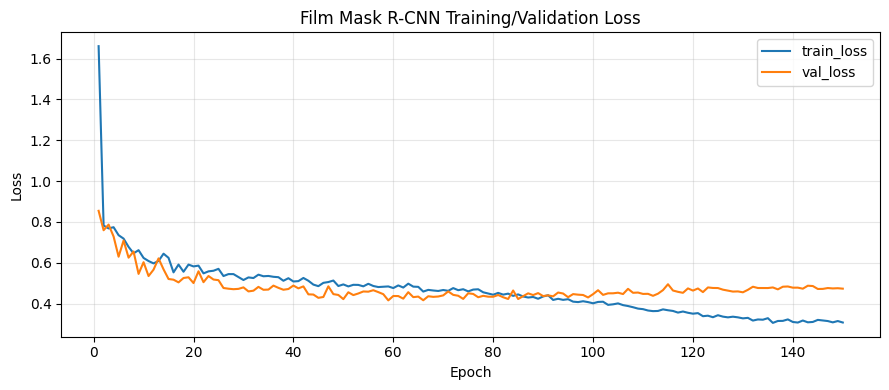

Saved /kaggle/working/film_training_loss.png


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(history) + 1), history, label='train_loss')
if 'val_history' in globals() and len(val_history) == len(history):
    plt.plot(range(1, len(val_history) + 1), val_history, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Film Mask R-CNN Training/Validation Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/film_training_loss.png', dpi=150)
plt.show()
print('Saved /kaggle/working/film_training_loss.png')

## 7. Sanity Check Predictions

Using: /kaggle/working/models/maskrcnn_film/maskrcnn_best.pth
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


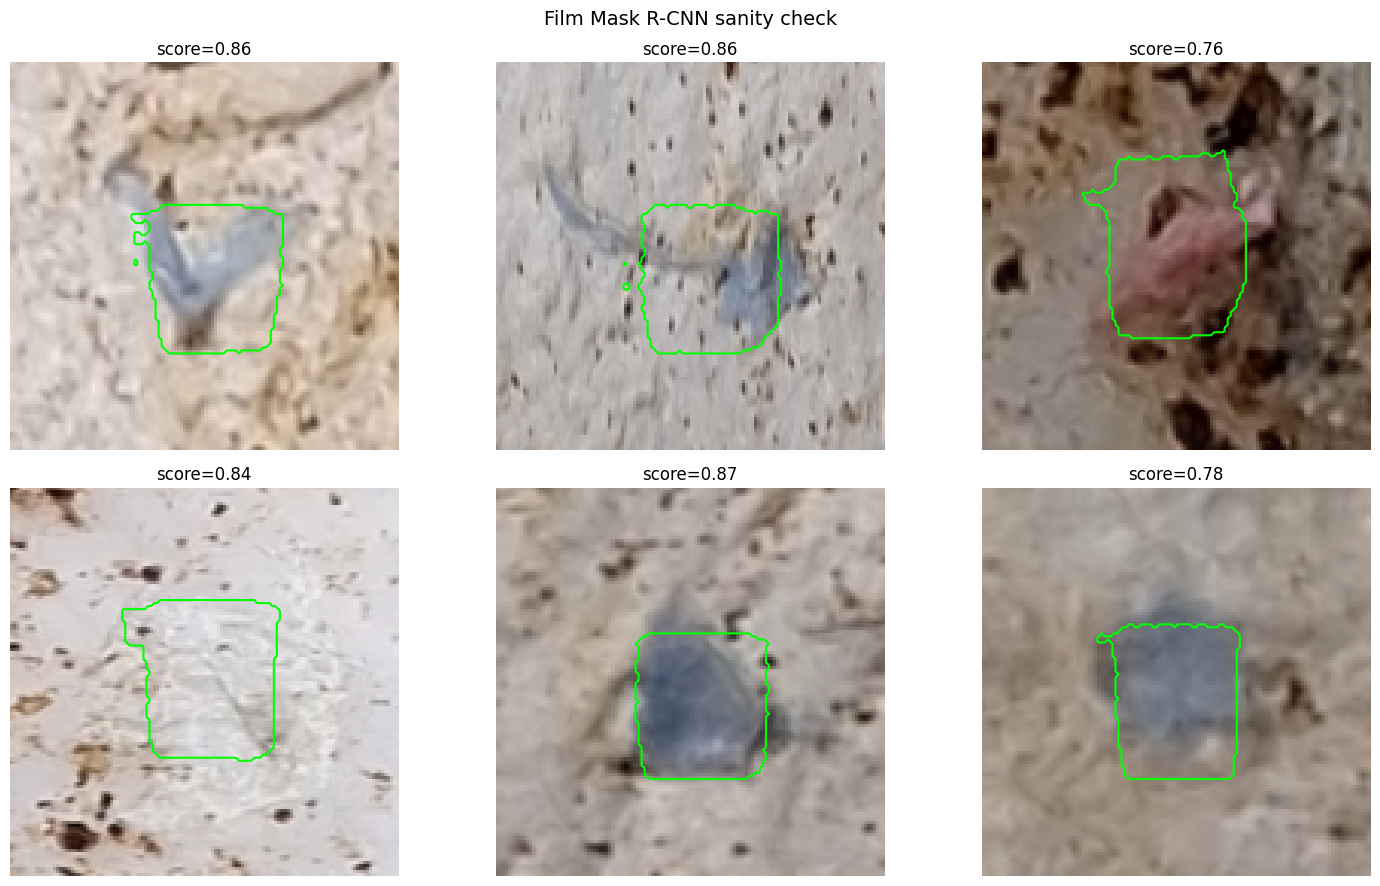

Saved /kaggle/working/film_sanity_predictions.png


In [7]:
import torchvision.transforms.functional as F

def find_best_ckpt():
    p = MODEL_ROOT / 'maskrcnn_film' / 'maskrcnn_best.pth'
    if p.exists():
        return p
    b = sorted((BACKUP_ROOT / 'film').glob('epoch_*/maskrcnn_best.pth')) if (BACKUP_ROOT / 'film').exists() else []
    if b:
        return b[-1]
    f = sorted(Path('/kaggle/working').rglob('maskrcnn_best.pth'))
    if f:
        return f[-1]
    raise FileNotFoundError('No maskrcnn_best.pth found')

best_ckpt = find_best_ckpt()
print('Using:', best_ckpt)

ckpt = torch.load(str(best_ckpt), map_location=device, weights_only=False)
model = get_model(num_classes=ckpt.get('num_classes', NUM_CLASSES), pretrained=False).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

samples = sorted((LOCAL_FILM_DIR / 'val' / 'images').glob('*.png'))
if not samples:
    samples = sorted((LOCAL_FILM_DIR / 'val' / 'images').glob('*.jpg'))
assert samples, 'No sample images found.'
samples = random.sample(samples, min(6, len(samples)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, ip in enumerate(samples):
    img_bgr = cv2.imread(str(ip))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (CROP_SIZE, CROP_SIZE))
    x = F.to_tensor(resized).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(x)[0]

    ax = axes[i]
    ax.imshow(resized)
    if len(out['masks']) > 0:
        bi = int(out['scores'].argmax().item())
        mk = out['masks'][bi, 0].detach().cpu().numpy() > 0.5
        sc = float(out['scores'][bi].item())
        ax.contour(mk, colors='lime', linewidths=1.5)
        ax.set_title(f'score={sc:.2f}')
    else:
        ax.set_title('no detection')
    ax.axis('off')

for j in range(len(samples), len(axes)):
    axes[j].axis('off')

plt.suptitle('Film Mask R-CNN sanity check', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/film_sanity_predictions.png', dpi=150)
plt.show()
print('Saved /kaggle/working/film_sanity_predictions.png')

## 8. Download

In [8]:
from pathlib import Path

model_dir = MODEL_ROOT / 'maskrcnn_film'
print('Model dir:', model_dir)
for p in sorted(model_dir.glob('*.pth')):
    print(f'- {p} ({p.stat().st_size / 1e6:.1f} MB)')

print('')
print('To download from Kaggle:')
print('1. Click Save Version')
print('2. Open Output tab')
print('3. Download /kaggle/working/models/maskrcnn_film/maskrcnn_best.pth')

Model dir: /kaggle/working/models/maskrcnn_film
- /kaggle/working/models/maskrcnn_film/maskrcnn_best.pth (525.9 MB)
- /kaggle/working/models/maskrcnn_film/maskrcnn_latest.pth (525.9 MB)

To download from Kaggle:
1. Click Save Version
2. Open Output tab
3. Download /kaggle/working/models/maskrcnn_film/maskrcnn_best.pth
